In [1]:
from LIBS.dutils import *
from LIBS.DVGAE import *


In [2]:
file_csv = "../DATA/dihedrals.csv"

dataset = create_dataset(file_csv, verbose=True)

# print info about the first sample

print(f"Dataset contains {len(dataset)} samples.")
print(f"First sample x shape: {dataset[0].x.shape}")
print(f"First sample edge_index shape: {dataset[0].edge_index.shape}")  




Reading dihedral angles from ../DATA/dihedrals.csv
Data shape: (20032, 11)
Reordered data shape: (20032, 11)
Data columns: ['Phi_1', 'Psi_1', 'Omega_1', 'Phi_2', 'Psi_2', 'Omega_2', 'Phi_3', 'Psi_3', 'Omega_3', 'Phi_4', 'Psi_4']
Dataframe head:         Phi_1       Psi_1     Omega_1       Phi_2       Psi_2     Omega_2  \
0 -131.160588  145.743224  169.970740 -137.721338  159.032146  167.127861   
1  -57.785341  125.849033  171.549933  -93.953460  159.210028 -176.857721   
2  -68.451687  164.619010  173.799352  -57.912327  141.092407 -179.672292   
3  -80.006760  -34.772377  163.340204  -62.796838  -42.951848  165.036695   
4  -64.699816  -44.467441  179.451404  -87.758079    1.220221 -178.037536   

        Phi_3       Psi_3     Omega_3       Phi_4       Psi_4  
0 -142.836320  144.440040  176.366651 -137.981410  156.916713  
1  -65.798071  144.862768  164.410361  -75.925157  138.219556  
2 -125.266176  160.505702  176.876316  -72.660163  151.342189  
3  -58.280550  -31.043675  174.29574

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(dataset, verbose=True)


Creating dataloaders ...
Train dataset size: 14022
Validation dataset size: 4006
Test dataset size: 2004
Number of features in the dataset: 2
Number of edges in the dataset: 10
Number of nodes in the dataset: 11
Number of features in the dataset: torch.Size([11, 2])



/home/clod/anaconda3/envs/openmm-dev/lib/python3.13/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [6]:
config = parse_config("config.template.in")


#### model parameters
# encoder
ENCODER_TYPE = config.get('ENCODER_TYPE', 'SAGE') # type of the encoder, can be GCN or SAGE
HIDDEN_ENCODER_CHANNELS = config.get('HIDDEN_ENCODER_CHANNELS', 256)
OUT_ENCODER_CHANNELS = config.get('OUT_ENCODER_CHANNELS', 128)
NUM_ENC_LAYERS = config.get('NUM_ENC_LAYERS', 5) # number of EGNN layers in the encoder
#ATTENTION_ENCODER = config.get('ATTENTION_ENCODER', True) # if True, attention is used in the encoder
LATENT_DIM = config.get('LATENT_DIM', 128) # latent dimension of the encoder, used to create the latent space
#TANH_ENCODER = config.get('TANH_ENCODER', True) # if True, the output of the encoder is passed through a tanh activation function (for positions)
#NORMALIZE_ENCODER = config.get('NORMALIZE_ENCODER', True) # if True, the encoder output is normalized
# decoder

HIDDEN_DECODER_CHANNELS = config.get('HIDDEN_DECODER_CHANNELS', 256)
NUM_DEC_LAYERS = config.get('NUM_DEC_LAYERS', 6)
# ATTENTION_DECODER = config.get('ATTENTION_DECODER', True)
# TANH_DECODER = config.get('TANH_DECODER', True) # if True, the output of the decoder is passed through a tanh activation function (for positions)
# NORMALIZE_DECODER = config.get('NORMALIZE_DECODER', True) # if True, the decoder output is normalized


#### training parameters
EPOCHS = config.get('EPOCHS', 50)
BATCHSIZE = config.get('BATCHSIZE', 64)
LEARNING_RATE = config.get('LEARNING_RATE', 1E-4)
WARMUP_EPOCHS = config.get('WARMUP_EPOCHS', 0) # number of epochs for the warm-up phase, if 0, no warm-up is applied
WEIGHT_DECAY = config.get('WEIGHT_DECAY', 0) # weight decay for the optimizer, set to 0 to disable weight decay ( bad idea using it for vae)

#### Scheduler parameters
USE_SCHEDULER = config.get('USE_SCHEDULER', False) # if True, the learning rate scheduler is used
SCHEDULER_PATIENCE = config.get('SCHEDULER_PATIENCE', 10) # number of epochs with no improvement after which learning rate will be reduced
SCHEDULER_FACTOR = config.get('SCHEDULER_FACTOR', 0.5) # factor by which the learning rate will be reduced. new_lr = lr * factor
SCHEDULER_TYPE = config.get('SCHEDULER_TYPE', 'ReduceLROnPlateau') # type of the scheduler, can be 'CosineAnnealingLR' or 'StepLR' or 'ReduceLROnPlateau'
SCHEDULER_THRESHOLD = config.get('SCHEDULER_THRESHOLD', 0.0001) # threshold for the scheduler, used to stop the training if the loss is below this value

# Beta annealing parameters
BETA = config.get('BETA', None)
CYCLIC_BETA = config.get('CYCLIC_BETA', False) # if True, the beta is cyclically annealed
CYCLE_LENGTH = config.get('CYCLE_LENGTH', 10) # number of epochs for the cyclic beta annealing
wait_epochs = config.get('wait_epochs', 0)
annealing_epochs = config.get('annealing_epochs', 50)
beta_min = config.get('beta_min', 0.00001)
beta_max = config.get('beta_max', 0.0001)

# Other parameters
DISABLE_TQDM = config.get('DISABLE_TQDM', False) # if True, the tqdm progress bar is disabled
SEED = config.get('SEED', 42) # seed for reproducibility
NAME_SIMULATION = config.get('NAME_SIMULATION', None ) # name of the simulation, used to create a folder to save the model
NAME_FOLDER = config.get('NAME_FOLDER', 'template') # name of the folder to save the model, if None, the folder will be created with the name of the model architecture and encoder type
CONTINUE_FROM = config.get('CONTINUE_FROM', None) # set the path to the model to continue training from, if None, the training will start from scratch
STARTING_EPOCH = config.get('STARTING_EPOCH', 0) # if CONTINUE_FROM is not None, the training will start from this epoch
#TEST_MODEL = config.get('TEST_MODEL', False) # if True, the model is tested after training
MIN_KL = config.get('MIN_KL', 0.0001) # minimum value for the KL divergence loss, if the KL divergence is below this value, the total loss is set to the reconstruction loss only

in_channels = dataset.num_features
out_channels = dataset[0].num_nodes

if ENCODER_TYPE == 'SAGE':
    encoder = SAGE_encoder(in_channels, LATENT_DIM, HIDDEN_ENCODER_CHANNELS, num_layers=NUM_ENC_LAYERS)
elif ENCODER_TYPE == 'GCN':
    encoder = GCN_encoder(in_channels, LATENT_DIM, HIDDEN_ENCODER_CHANNELS, num_layers=NUM_ENC_LAYERS)
    

decoder = MLP_Decoder(LATENT_DIM, out_channels, dataset.num_features, HIDDEN_DECODER_CHANNELS, num_layers=NUM_DEC_LAYERS)


model = DVGAE(encoder, decoder)

print_model_summary(model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path = "/home/clod/Desktop/THESIS_2/DIHEDRALS/RUNS/implementation/simulation_13/model_epoch_100.pth"

model.load_state_dict(torch.load(path, map_location=device))

model = model.to(device)

MODEL SUMMARY
encoder.conv1.lin_l                                | Linear(2, 128, bias=True)                                    |        384 |        384
encoder.conv1.lin_r                                | Linear(2, 128, bias=False)                                   |        256 |        256
encoder.conv2.lin_l                                | Linear(128, 128, bias=True)                                  |     16,512 |     16,512
encoder.conv2.lin_r                                | Linear(128, 128, bias=False)                                 |     16,384 |     16,384
encoder.conv3.lin_l                                | Linear(128, 128, bias=True)                                  |     16,512 |     16,512
encoder.conv3.lin_r                                | Linear(128, 128, bias=False)                                 |     16,384 |     16,384
encoder.conv4.lin_l                                | Linear(128, 128, bias=True)                                  |     16,512 |     16,512
encode

In [28]:
gen_data = []
for _ in range(1000):
    model.eval()
    z = torch.randn(1, LATENT_DIM).to(device)  # random latent vector for testing the decoder
    x_recon = model.decoder(z)  # get the reconstructed data from the decoder
    gen_data.append(inverse_transform(x_recon).detach().cpu().squeeze().numpy())


In [29]:
columns = ['Phi_1', 'Psi_1', 'Omega_1', 'Phi_2', 'Psi_2', 'Omega_2', 'Phi_3', 'Psi_3', 'Omega_3', 'Phi_4', 'Psi_4']

df = pd.DataFrame(gen_data, columns=columns)

df

,Phi_1,Psi_1,Omega_1,Phi_2,Psi_2,Omega_2,Phi_3,Psi_3,Omega_3,Phi_4,Psi_4
0,-85.967934,148.095062,179.191498,-48.390518,33.990974,-179.024384,-63.136150,14.788255,-179.000305,-97.669518,71.515556
1,-82.399406,144.431137,179.703323,-64.339699,17.703678,-177.721527,-91.322853,38.284611,-177.927216,-99.562546,107.690628
2,-83.904343,145.379990,179.871994,-77.989792,15.993401,-179.088211,-94.509148,85.209869,-179.233093,-98.705231,122.016029
3,-84.376106,146.991608,179.903732,-82.752670,12.856909,-178.687332,-97.877937,119.438347,178.854752,-98.720177,130.666718
4,-82.635811,141.985489,177.795044,-2.256273,26.053392,-179.544495,-54.032852,12.896049,-176.931839,-98.927734,69.590103
...,...,...,...,...,...,...,...,...,...,...,...
995,-87.535248,150.266083,178.838806,-89.051048,15.930686,-179.110657,-101.043045,147.283218,178.859253,-97.711052,138.259964
996,-84.834007,146.470428,178.790649,-24.618792,31.204144,-179.172684,-35.173191,11.802407,-178.128601,-97.457779,63.625748
997,-73.069992,7.871801,-178.255569,-73.539513,24.733770,-179.633698,-83.371368,22.425684,-177.688370,-97.819206,113.059059
998,-83.968277,144.860199,-179.841934,-83.967880,22.531620,179.558838,-95.315109,108.636673,179.341461,-99.345383,126.771988


In [25]:
df_data = pd.read_csv(file_csv)
df_data = df_data[columns]
df_data.head()

,Phi_1,Psi_1,Omega_1,Phi_2,Psi_2,Omega_2,Phi_3,Psi_3,Omega_3,Phi_4,Psi_4
0,-131.160588,145.743224,169.970740,-137.721338,159.032146,167.127861,-142.836320,144.440040,176.366651,-137.981410,156.916713
1,-57.785341,125.849033,171.549933,-93.953460,159.210028,-176.857721,-65.798071,144.862768,164.410361,-75.925157,138.219556
2,-68.451687,164.619010,173.799352,-57.912327,141.092407,-179.672292,-125.266176,160.505702,176.876316,-72.660163,151.342189
3,-80.006760,-34.772377,163.340204,-62.796838,-42.951848,165.036695,-58.280550,-31.043675,174.295740,-58.818817,-34.341431
4,-64.699816,-44.467441,179.451404,-87.758079,1.220221,-178.037536,-102.640205,-71.341074,-170.808912,-152.000383,153.048354


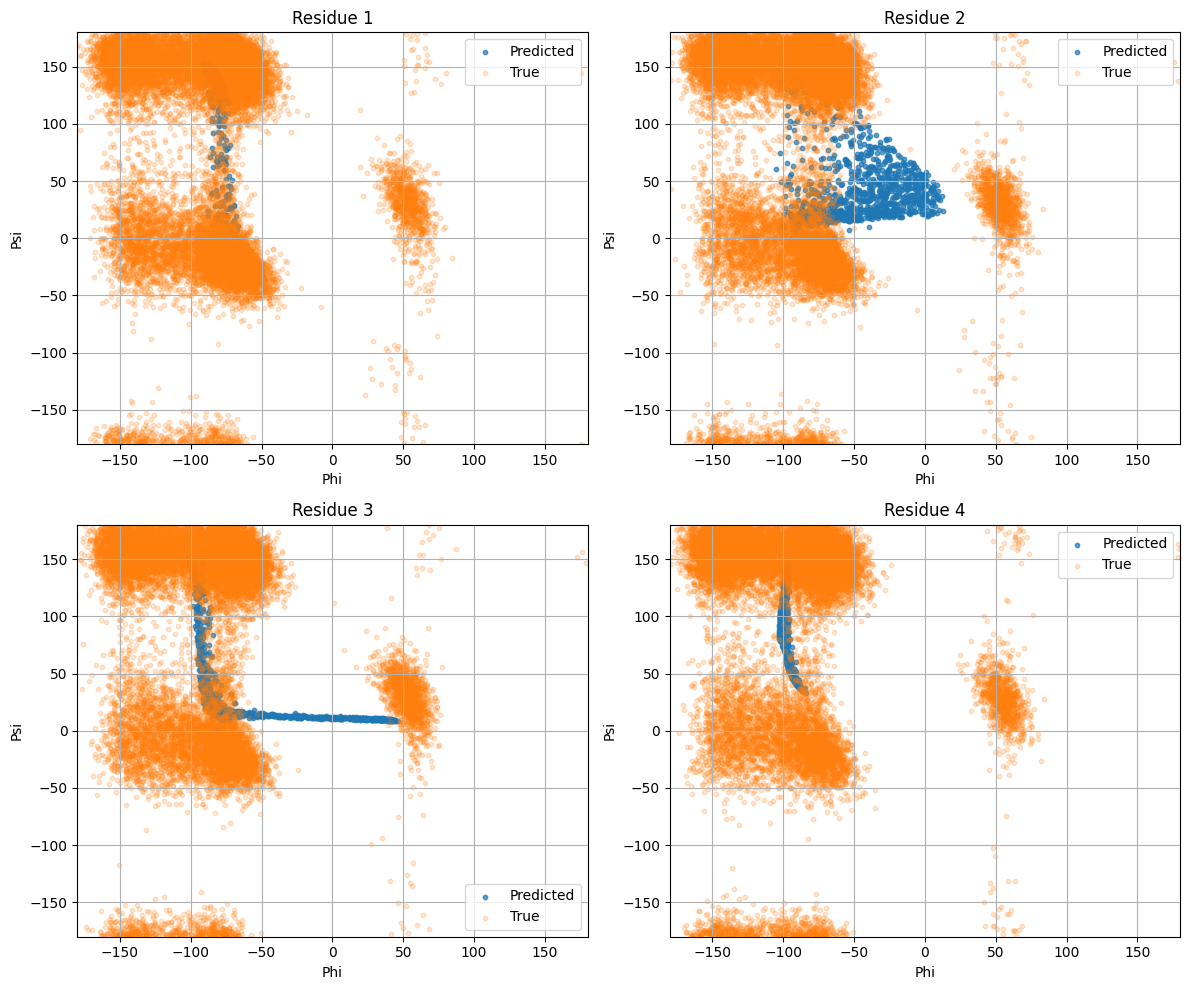

In [ ]:
def ramachandran_plot(df_pred, df_true, save_path=None):
    """
    Create a Ramachandran plot for each residue in the dataset.
    Each residue is represented by a scatter plot of its phi and psi angles.    
    Parameters:
    df_pred (pd.DataFrame): DataFrame containing predicted phi and psi angles for residues.
    df_true (pd.DataFrame): DataFrame containing true phi and psi angles for residues.
    """

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    for i in range(4):
        axs[i].scatter(df_pred[f'Phi_{i+1}'], df_pred[f'Psi_{i+1}'], alpha=0.7, label='Predicted', s=10)
        axs[i].scatter(df_true[f'Phi_{i+1}'], df_true[f'Psi_{i+1}'], alpha=0.2, label='True', s=10)
        axs[i].set_title(f'Residue {i+1}')
        axs[i].set_xlabel('Phi')
        axs[i].set_ylabel('Psi')
        axs[i].set_xlim(-180, 180)
        axs[i].set_ylim(-180, 180)
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    else:   
        plt.show()

ramachandran_plot(df, df_data)


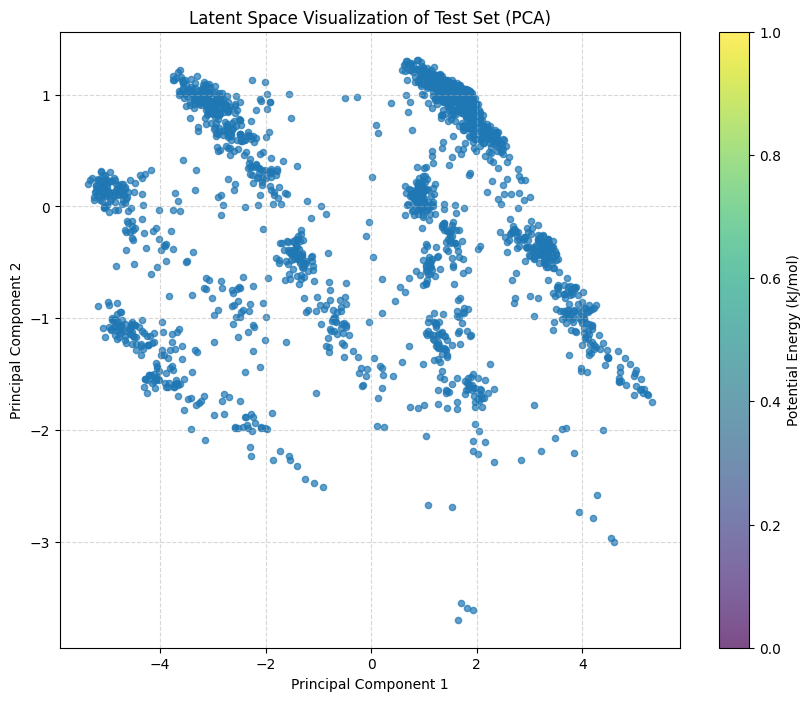

In [ ]:
from tqdm import tqdm

def analyze_latent_space(model, dataloader, device, file_path, verbose=True):
    """Encodes the dataset, performs PCA, and plots the latent space colored by energy."""
    model.eval()
    latent_vectors = []
  
    with torch.no_grad():
        for data in tqdm(dataloader, desc="Analyzing Latent Space", leave=False):
            data = data.to(device)
            mean, _ = model.encoder(data.x, data.edge_index, data.batch)  # get the mean from the encoder
            latent_vectors.append(mean.cpu())

    latent_vectors = torch.cat(latent_vectors, dim=0).numpy()
    

    # Use PCA to reduce to 2D if latent dimension is greater than 2
    if latent_vectors.shape[1] > 2:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        latent_vectors = pca.fit_transform(latent_vectors)
    

    plt.figure(figsize=(10, 8))
    points = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], s=20, alpha=0.7)
    plt.title('Latent Space Visualization of Test Set (PCA)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(f"{file_path}/latent_space_pca.png")
    plt.close()
  


analyze_latent_space(model, test_loader, device, file_path="/home/clod/Desktop/THESIS_2/DIHEDRALS/RUNS/implementation/simulation_13", verbose=True)


